In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Leitura da base limpa/padronizada
df_fuzzy = pd.read_csv("base_modelagem_aviacao.csv")

C:\Users\FelipePedrosodeLimaB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df_fuzzy.info()

<class 'pandas.DataFrame'>
RangeIndex: 34939 entries, 0 to 34938
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ocorrencia_classificacao         34939 non-null  str    
 1   ocorrencia_latitude              34939 non-null  str    
 2   ocorrencia_longitude             34939 non-null  str    
 3   ocorrencia_cidade                34939 non-null  str    
 4   ocorrencia_uf                    34939 non-null  str    
 5   ocorrencia_pais                  34939 non-null  str    
 6   ocorrencia_aerodromo             34939 non-null  str    
 7   investigacao_aeronave_liberada   34939 non-null  str    
 8   investigacao_status              34938 non-null  str    
 9   divulgacao_relatorio_publicado   34939 non-null  str    
 10  total_recomendacoes              34939 non-null  int64  
 11  total_aeronaves_envolvidas       34939 non-null  int64  
 12  ocorrencia_saida_pista       

# BLOCO 1 — aeronave_nivel_dano

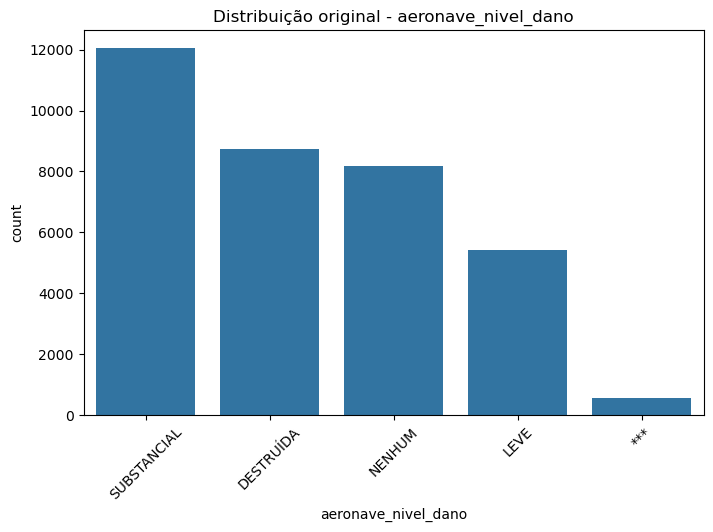

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_fuzzy,
    x="aeronave_nivel_dano",
    order=df_fuzzy["aeronave_nivel_dano"].value_counts().index
)

plt.title("Distribuição original - aeronave_nivel_dano")
plt.xticks(rotation=45)
plt.show()


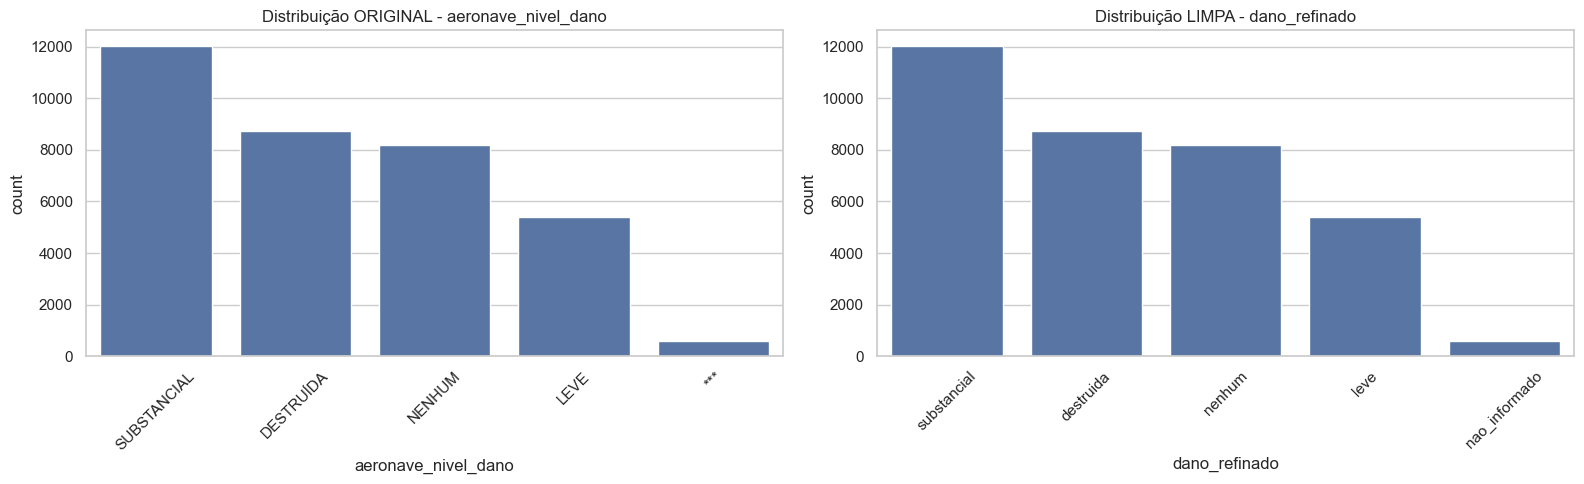

Distribuição percentual (dano_refinado):

dano_refinado
substancial      0.345
destruida        0.250
nenhum           0.234
leve             0.155
nao_informado    0.016
Name: proportion, dtype: float64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# -------------------------------
# 1. Gráfico original
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=df_fuzzy,
    x="aeronave_nivel_dano",
    order=df_fuzzy["aeronave_nivel_dano"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribuição ORIGINAL - aeronave_nivel_dano")
axes[0].tick_params(axis='x', rotation=45)


# -------------------------------
# 2. Limpeza da variável
# -------------------------------
def limpar_dano(dano):
    dano = str(dano).upper().strip()
    
    if "DESTRU" in dano:
        return "destruida"
    elif "SUBSTANCIAL" in dano:
        return "substancial"
    elif "LEVE" in dano:
        return "leve"
    elif "NENHUM" in dano:
        return "nenhum"
    else:
        return "nao_informado"

df_fuzzy["dano_refinado"] = df_fuzzy["aeronave_nivel_dano"].apply(limpar_dano)


# -------------------------------
# 3. Gráfico após limpeza
# -------------------------------
sns.countplot(
    data=df_fuzzy,
    x="dano_refinado",
    order=df_fuzzy["dano_refinado"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribuição LIMPA - dano_refinado")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# -------------------------------
# 4. Proporções (ESSENCIAL)
# -------------------------------
print("Distribuição percentual (dano_refinado):\n")
print(df_fuzzy["dano_refinado"].value_counts(normalize=True).round(3))


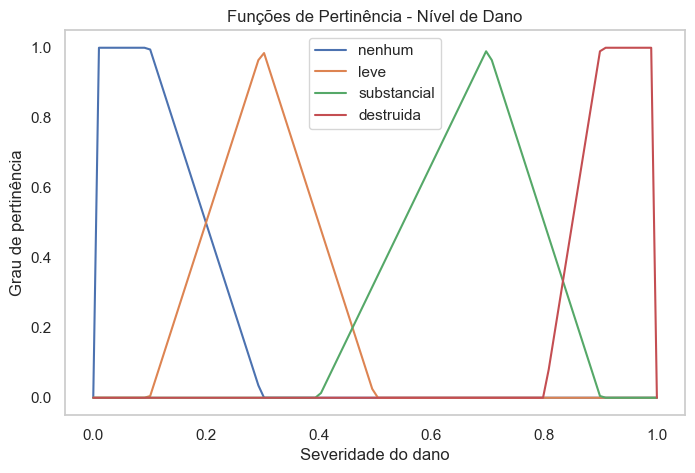


Testes de fuzzificação:

Valor: 0.1
{'nenhum': np.float64(0.999999995), 'leve': np.float64(0.0), 'substancial': np.float64(0.0), 'destruida': np.float64(0.0)}
------------------------------
Valor: 0.3
{'nenhum': np.float64(0.0), 'leve': np.float64(0.999999995), 'substancial': np.float64(0.0), 'destruida': np.float64(0.0)}
------------------------------
Valor: 0.5
{'nenhum': np.float64(0.0), 'leve': np.float64(0.0), 'substancial': np.float64(0.3333333322222222), 'destruida': np.float64(0.0)}
------------------------------
Valor: 0.75
{'nenhum': np.float64(0.0), 'leve': np.float64(0.0), 'substancial': np.float64(0.7499999962499999), 'destruida': np.float64(0.0)}
------------------------------
Valor: 0.95
{'nenhum': np.float64(0.0), 'leve': np.float64(0.0), 'substancial': np.float64(0.0), 'destruida': np.float64(1.0)}
------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Variável ordinal
# A fuzzyficação é justificada pela progressão natural
# de severidade dos danos aeronáuticos.

# -------------------------
# Universo do problema
# -------------------------
x = np.linspace(0, 1, 100)

# -------------------------
# Parâmetros editáveis
# -------------------------
params = {
    "nenhum":      {"type": "trap", "points": [0.0, 0.0, 0.1, 0.3]},
    "leve":        {"type": "tri",  "points": [0.1, 0.3, 0.5]},
    "substancial": {"type": "tri",  "points": [0.4, 0.7, 0.9]},
    "destruida":   {"type": "trap", "points": [0.8, 0.9, 1.0, 1.0]},
}

# -------------------------
# Funções de pertinência
# -------------------------
def triangular(x, a, b, c):
    return np.maximum(
        np.minimum((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9)),
        0
    )

def trapezoidal(x, a, b, c, d):
    return np.maximum(
        np.minimum(
            np.minimum((x - a) / (b - a + 1e-9), 1),
            (d - x) / (d - c + 1e-9)
        ),
        0
    )

# -------------------------
# Fuzzificação
# -------------------------
def fuzzify(value):
    memberships = {}
    
    for label, p in params.items():
        pts = p["points"]
        
        if p["type"] == "tri":
            a, b, c = pts
            memberships[label] = triangular(value, a, b, c)
        
        elif p["type"] == "trap":
            a, b, c, d = pts
            memberships[label] = trapezoidal(value, a, b, c, d)
    
    return memberships

# -------------------------
# Plot das funções
# -------------------------
plt.figure(figsize=(8, 5))

for label, p in params.items():
    pts = p["points"]
    
    if p["type"] == "tri":
        a, b, c = pts
        y = triangular(x, a, b, c)
    
    elif p["type"] == "trap":
        a, b, c, d = pts
        y = trapezoidal(x, a, b, c, d)
    
    plt.plot(x, y, label=label)

plt.title("Funções de Pertinência - Nível de Dano")
plt.xlabel("Severidade do dano")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid()

plt.show()

# -------------------------
# Testes de fuzzificação
# -------------------------
print("\nTestes de fuzzificação:\n")

valores_teste = [0.1, 0.3, 0.5, 0.75, 0.95]

for v in valores_teste:
    print(f"Valor: {v}")
    print(fuzzify(v))
    print("-" * 30)

# BLOCO 2 — fator_area

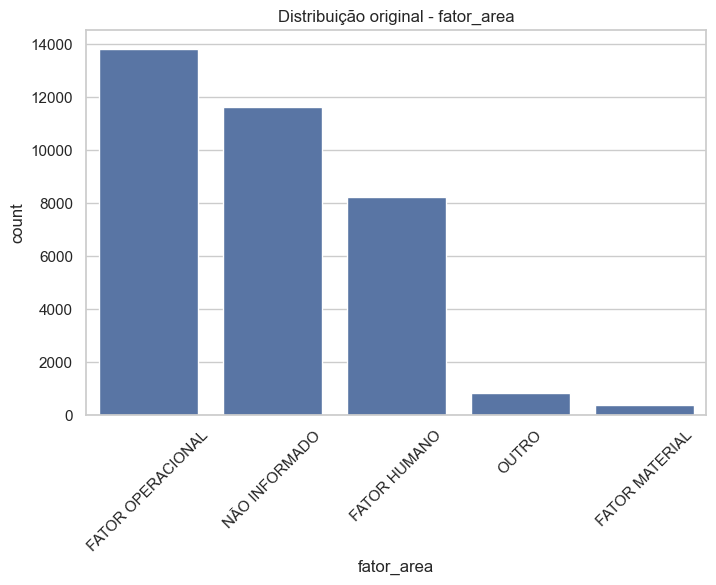

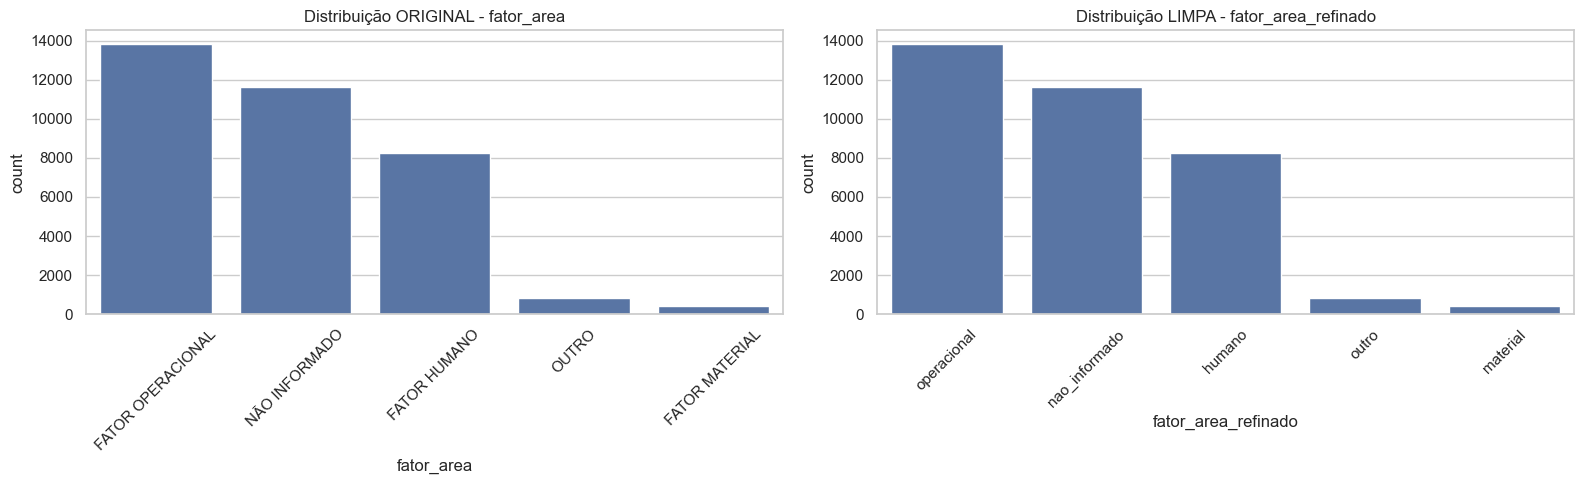


Distribuição percentual (fator_area_refinado):

fator_area_refinado
operacional      0.396
nao_informado    0.333
humano           0.236
outro            0.024
material         0.012
Name: proportion, dtype: float64


In [6]:
# ============================================================
# BLOCO 2 — Análise e preparação da variável fator_area
# Objetivo:
# - Explorar a distribuição original
# - Padronizar categorias
# - Avaliar a representatividade das classes
#
# OBSERVAÇÃO METODOLÓGICA:
# Esta variável NÃO foi fuzzyficada.
#
# Justificativa:
# Embora seja uma variável categórica relevante para a
# classificação das ocorrências aeronáuticas, suas categorias
# (humano, operacional, material, etc.) não representam uma
# progressão ordinal natural.
#
# A atribuição de graus de pertinência exigiria pesos
# subjetivos não sustentados por conhecimento especializado
# do domínio aeronáutico.
#
# Assim, a variável foi mantida em sua forma categórica
# original para preservar a interpretabilidade e o rigor
# metodológico da proposta.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Distribuição original
# -------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_fuzzy,
    x="fator_area",
    order=df_fuzzy["fator_area"].value_counts().index
)

plt.title("Distribuição original - fator_area")
plt.xticks(rotation=45)
plt.show()


# -------------------------------
# Comparação original x refinado
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=df_fuzzy,
    x="fator_area",
    order=df_fuzzy["fator_area"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribuição ORIGINAL - fator_area")
axes[0].tick_params(axis='x', rotation=45)


# -------------------------------
# Padronização das categorias
# -------------------------------

def limpar_fator_area(x):

    x = str(x).upper().strip()

    if "HUMANO" in x:
        return "humano"

    elif "OPER" in x:
        return "operacional"

    elif "MATERIAL" in x:
        return "material"

    elif "OUTRO" in x:
        return "outro"

    else:
        return "nao_informado"


df_fuzzy["fator_area_refinado"] = (
    df_fuzzy["fator_area"]
    .apply(limpar_fator_area)
)


# -------------------------------
# Distribuição após limpeza
# -------------------------------

sns.countplot(
    data=df_fuzzy,
    x="fator_area_refinado",
    order=df_fuzzy["fator_area_refinado"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribuição LIMPA - fator_area_refinado")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# -------------------------------
# Distribuição percentual
# -------------------------------

print("\nDistribuição percentual (fator_area_refinado):\n")

print(
    df_fuzzy["fator_area_refinado"]
    .value_counts(normalize=True)
    .round(3)
)

# Bloco aeronave_pmd

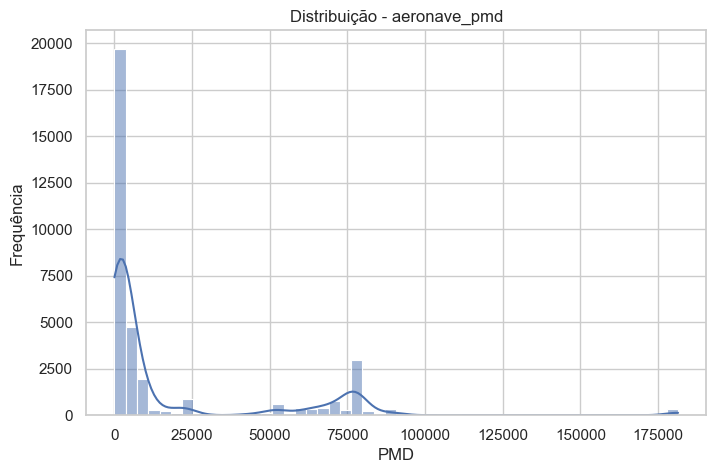

count     34367.000000
mean      18741.793246
std       32341.179221
min           1.000000
25%        1454.000000
50%        2404.000000
75%       10433.000000
max      181436.630000
Name: pmd_limpo, dtype: float64


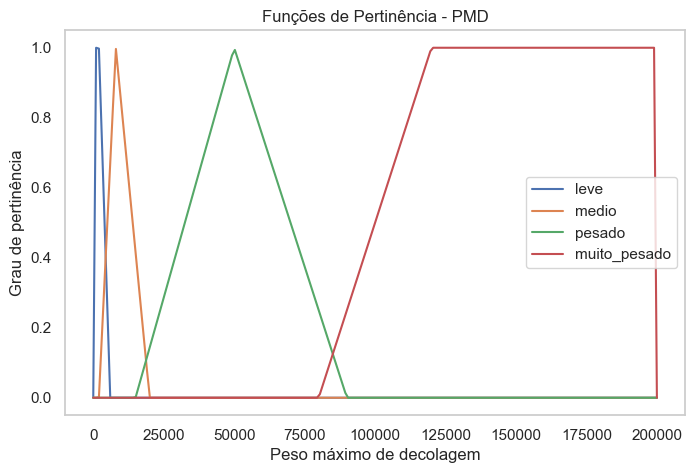


Testes PMD:

PMD: 1000
{'leve': np.float64(1.0), 'medio': np.float64(0.0), 'pesado': np.float64(0.0), 'muito_pesado': np.float64(0.0)}
------------------------------
PMD: 8000
{'leve': np.float64(0.0), 'medio': np.float64(0.9999999999998332), 'pesado': np.float64(0.0), 'muito_pesado': np.float64(0.0)}
------------------------------
PMD: 30000
{'leve': np.float64(0.0), 'medio': np.float64(0.0), 'pesado': np.float64(0.4285714285714164), 'muito_pesado': np.float64(0.0)}
------------------------------
PMD: 100000
{'leve': np.float64(0.0), 'medio': np.float64(0.0), 'pesado': np.float64(0.0), 'muito_pesado': np.float64(0.49999999999998757)}
------------------------------


In [7]:
# ============================================================
# BLOCO X — Análise e Fuzzyficação da variável aeronave_pmd
#
# Objetivo:
# - Explorar a distribuição do PMD
# - Tratar valores inconsistentes
# - Definir conjuntos fuzzy linguísticos
# - Representar diferentes portes de aeronaves
#
# JUSTIFICATIVA METODOLÓGICA:
#
# O PMD (Peso Máximo de Decolagem) é uma variável
# numérica contínua, característica adequada para
# representação através de conjuntos fuzzy.
#
# Diferentemente de variáveis categóricas sem ordem
# natural, o PMD apresenta uma escala contínua onde
# transições graduais são mais realistas do que
# limiares rígidos.
#
# Os conjuntos fuzzy foram definidos empiricamente
# a partir da distribuição observada dos dados,
# permitindo sobreposição gradual entre categorias
# adjacentes:
#
# leve → médio → pesado → muito pesado
#
# Essa abordagem permite representar a incerteza
# inerente à classificação de aeronaves próximas aos
# limites das categorias.
# ============================================================

# ============================================================
# 1. Distribuição original
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df_fuzzy["aeronave_pmd"],
    bins=50,
    kde=True
)

plt.title("Distribuição - aeronave_pmd")
plt.xlabel("PMD")
plt.ylabel("Frequência")
plt.show()


# ============================================================
# 2. Limpeza da variável
# ============================================================

df_fuzzy["pmd_limpo"] = df_fuzzy["aeronave_pmd"]

df_fuzzy.loc[
    df_fuzzy["pmd_limpo"] <= 0,
    "pmd_limpo"
] = np.nan

print(df_fuzzy["pmd_limpo"].describe())


# ============================================================
# 3. Definição dos conjuntos fuzzy
# ============================================================

params_pmd = {

    "leve": {
        "type": "trap",
        "points": [0, 0, 2000, 6000]
    },

    "medio": {
        "type": "tri",
        "points": [2000, 8000, 20000]
    },

    "pesado": {
        "type": "tri",
        "points": [15000, 50000, 90000]
    },

    "muito_pesado": {
        "type": "trap",
        "points": [80000, 120000, 200000, 200000]
    }
}


# ============================================================
# 4. Fuzzyficação
# ============================================================

def fuzzify_pmd(value):

    memberships = {}

    for label, p in params_pmd.items():

        pts = p["points"]

        if p["type"] == "tri":

            a, b, c = pts

            memberships[label] = triangular(
                value,
                a,
                b,
                c
            )

        elif p["type"] == "trap":

            a, b, c, d = pts

            memberships[label] = trapezoidal(
                value,
                a,
                b,
                c,
                d
            )

    return memberships


# ============================================================
# 5. Visualização das funções de pertinência
# ============================================================

x_pmd = np.linspace(0, 200000, 200)

plt.figure(figsize=(8,5))

for label, p in params_pmd.items():

    pts = p["points"]

    if p["type"] == "tri":

        a, b, c = pts
        y = triangular(x_pmd, a, b, c)

    elif p["type"] == "trap":

        a, b, c, d = pts
        y = trapezoidal(x_pmd, a, b, c, d)

    plt.plot(x_pmd, y, label=label)

plt.title("Funções de Pertinência - PMD")
plt.xlabel("Peso máximo de decolagem")
plt.ylabel("Grau de pertinência")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. Testes de fuzzificação
# ============================================================

print("\nTestes PMD:\n")

valores = [1000, 8000, 30000, 100000]

for v in valores:

    print(f"PMD: {v}")

    print(
        fuzzify_pmd(v)
    )

    print("-" * 30)

# Bloco ocorrencia_tipo

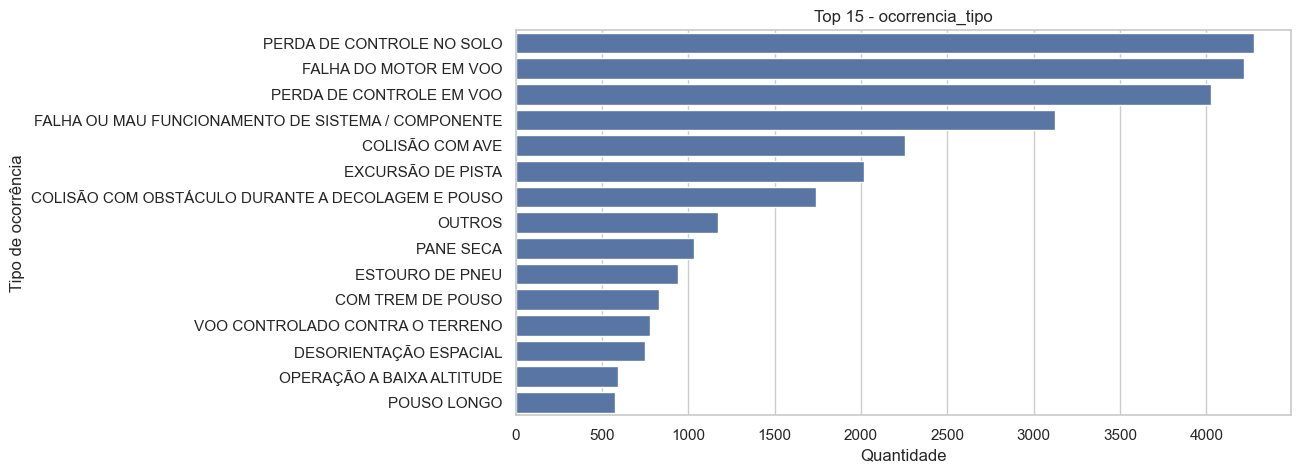


Top 20 categorias:

ocorrencia_tipo
PERDA DE CONTROLE NO SOLO                             4274
FALHA DO MOTOR EM VOO                                 4217
PERDA DE CONTROLE EM VOO                              4026
FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE    3123
COLISÃO COM AVE                                       2256
EXCURSÃO DE PISTA                                     2018
COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO     1742
OUTROS                                                1170
PANE SECA                                             1034
ESTOURO DE PNEU                                        942
COM TREM DE POUSO                                      833
VOO CONTROLADO CONTRA O TERRENO                        777
DESORIENTAÇÃO ESPACIAL                                 748
OPERAÇÃO A BAIXA ALTITUDE                              594
POUSO LONGO                                            578
COLISÃO COM OBSTÁCULOS NO SOLO                         481
TRÁFEGO AÉREO      

In [9]:
# ============================================================
# BLOCO  — Análise da variável ocorrencia_tipo
#
# Objetivo:
# - Explorar os tipos de ocorrência registrados
# - Avaliar a distribuição das categorias
# - Verificar a necessidade de agrupamentos
#
# JUSTIFICATIVA METODOLÓGICA:
#
# A variável ocorrencia_tipo apresenta dezenas de
# categorias distintas relacionadas à natureza da
# ocorrência aeronáutica.
#
# Inicialmente foram avaliadas estratégias de
# agrupamento e fuzzyficação. Entretanto, observou-se
# que essas categorias não representam uma escala
# ordinal natural de severidade.
#
# Por exemplo:
#
# - Falha técnica
# - Colisão com ave
# - Incêndio
# - Perda de controle
#
# representam naturezas diferentes de ocorrência,
# mas não níveis crescentes ou decrescentes de risco.
#
# A atribuição de pesos ou escores fuzzy exigiria
# conhecimento especializado do domínio aeronáutico,
# podendo introduzir subjetividade ao modelo.
#
# Dessa forma, optou-se por NÃO fuzzyficar esta
# variável e preservar as categorias relevantes
# diretamente identificadas pela Árvore de Decisão.
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Top ocorrências originais
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df_fuzzy,
    y="ocorrencia_tipo",
    order=df_fuzzy["ocorrencia_tipo"]
    .value_counts()
    .head(15)
    .index
)

plt.title("Top 15 - ocorrencia_tipo")
plt.xlabel("Quantidade")
plt.ylabel("Tipo de ocorrência")

plt.show()


# ============================================================
# 2. Distribuição das principais categorias
# ============================================================

print("\nTop 20 categorias:\n")

print(
    df_fuzzy["ocorrencia_tipo"]
    .value_counts()
    .head(20)
)


# ============================================================
# 3. Distribuição percentual
# ============================================================

print("\nDistribuição percentual (Top 20):\n")

print(
    (
        df_fuzzy["ocorrencia_tipo"]
        .value_counts(normalize=True)
        .head(20)
        * 100
    ).round(2)
)

# Preparação para Criação das Regras Fuzzy

In [11]:
# ============================================================
# BLOCO X — Tradução conservadora das regras da AD para lógica fuzzy híbrida
#
# Objetivo:
# - Traduzir as 8 regras extraídas da Árvore de Decisão interpretável
# - Preservar variáveis categóricas nominais em seus valores originais
# - Fuzzyficar apenas variáveis metodologicamente defensáveis
#
# DECISÃO METODOLÓGICA:
#
# Variáveis fuzzyficadas:
# - aeronave_nivel_dano
#   Motivo: variável categórica ordinal, com progressão natural de severidade:
#   nenhum → leve → substancial → destruída.
#
# - aeronave_pmd
#   Motivo: variável numérica contínua, adequada para representar transições
#   graduais entre portes de aeronaves.
#
# Variáveis NÃO fuzzyficadas:
# - fator_area
# - ocorrencia_tipo
#
# Motivo:
# Essas variáveis são categóricas nominais e não possuem ordem natural.
# Portanto, não foram convertidas em pesos, scores ou graus de pertinência.
#
# Estratégia conservadora:
# As categorias originais são preservadas e utilizadas como condições lógicas:
#
# - fator_area = "NÃO INFORMADO"
# - fator_area != "NÃO INFORMADO"
# - ocorrencia_tipo = "COM TREM DE POUSO"
# - ocorrencia_tipo != "COM TREM DE POUSO"
#
# Observação técnica:
# O scikit-fuzzy não avalia diretamente strings dentro de ctrl.Rule.
# Portanto, essas condições categóricas devem ser aplicadas como filtros
# lógicos antes da inferência fuzzy, ou dentro de uma camada híbrida de
# ativação das regras.
# ============================================================


# ============================================================
# REGRA 1
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO <= 0.50
E aeronave_nivel_dano LEVE <= 0.50
E aeronave_nivel_dano NENHUM <= 0.50
→ ACIDENTE

Interpretação conservadora:

- fator_area NÃO INFORMADO <= 0.50 significa:
  fator_area != "NÃO INFORMADO"

- dano LEVE <= 0.50 e dano NENHUM <= 0.50 significam:
  dano não é leve e não é nenhum.

Como os níveis de dano possuem ordem natural de severidade,
essa condição é traduzida para:

dano é substancial OU destruída.

Regra fuzzy híbrida:

SE fator_area != "NÃO INFORMADO"
E dano é substancial OU destruída
→ ACIDENTE
"""

# Condição categórica preservada:
# fator_area != "NÃO INFORMADO"

# Condição fuzzy:
# dano["substancial"] | dano["destruida"]

# Consequente:
# risco["acidente"]


# ============================================================
# REGRA 2
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO <= 0.50
E aeronave_nivel_dano LEVE <= 0.50
E aeronave_nivel_dano NENHUM > 0.50
→ INCIDENTE GRAVE

Interpretação conservadora:

- fator_area != "NÃO INFORMADO"
- dano é nenhum.

Regra fuzzy híbrida:

SE fator_area != "NÃO INFORMADO"
E dano é nenhum
→ INCIDENTE GRAVE
"""

# Condição categórica preservada:
# fator_area != "NÃO INFORMADO"

# Condição fuzzy:
# dano["nenhum"]

# Consequente:
# risco["incidente_grave"]


# ============================================================
# REGRA 3
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO <= 0.50
E aeronave_nivel_dano LEVE > 0.50
E aeronave_pmd <= 70266.50
→ INCIDENTE GRAVE

Interpretação conservadora:

- fator_area != "NÃO INFORMADO"
- dano é leve.
- PMD não está na faixa mais elevada.

Regra fuzzy híbrida:

SE fator_area != "NÃO INFORMADO"
E dano é leve
E PMD é leve OU médio OU pesado
→ INCIDENTE GRAVE
"""

# Condição categórica preservada:
# fator_area != "NÃO INFORMADO"

# Condição fuzzy:
# dano["leve"] & (pmd["leve"] | pmd["medio"] | pmd["pesado"])

# Consequente:
# risco["incidente_grave"]


# ============================================================
# REGRA 4
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO <= 0.50
E aeronave_nivel_dano LEVE > 0.50
E aeronave_pmd > 70266.50
→ INCIDENTE

Interpretação conservadora:

- fator_area != "NÃO INFORMADO"
- dano é leve.
- PMD está em faixa muito elevada.

Regra fuzzy híbrida:

SE fator_area != "NÃO INFORMADO"
E dano é leve
E PMD é muito pesado
→ INCIDENTE
"""

# Condição categórica preservada:
# fator_area != "NÃO INFORMADO"

# Condição fuzzy:
# dano["leve"] & pmd["muito_pesado"]

# Consequente:
# risco["incidente"]


# ============================================================
# REGRA 5
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO > 0.50
E aeronave_nivel_dano SUBSTANCIAL <= 0.50
E aeronave_nivel_dano DESTRUÍDA <= 0.50
→ INCIDENTE

Interpretação conservadora:

- fator_area = "NÃO INFORMADO"
- dano não é substancial.
- dano não é destruída.

Como os níveis de dano possuem ordem natural, essa condição é traduzida para:

dano é nenhum OU leve.

Regra fuzzy híbrida:

SE fator_area = "NÃO INFORMADO"
E dano é nenhum OU leve
→ INCIDENTE
"""

# Condição categórica preservada:
# fator_area = "NÃO INFORMADO"

# Condição fuzzy:
# dano["nenhum"] | dano["leve"]

# Consequente:
# risco["incidente"]


# ============================================================
# REGRA 6
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO > 0.50
E aeronave_nivel_dano SUBSTANCIAL <= 0.50
E aeronave_nivel_dano DESTRUÍDA > 0.50
→ ACIDENTE

Interpretação conservadora:

- fator_area = "NÃO INFORMADO"
- dano é destruída.

Regra fuzzy híbrida:

SE fator_area = "NÃO INFORMADO"
E dano é destruída
→ ACIDENTE
"""

# Condição categórica preservada:
# fator_area = "NÃO INFORMADO"

# Condição fuzzy:
# dano["destruida"]

# Consequente:
# risco["acidente"]


# ============================================================
# REGRA 7
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO > 0.50
E aeronave_nivel_dano SUBSTANCIAL > 0.50
E ocorrencia_tipo COM TREM DE POUSO <= 0.50
→ ACIDENTE

Interpretação conservadora:

- fator_area = "NÃO INFORMADO"
- dano é substancial.
- ocorrencia_tipo != "COM TREM DE POUSO"

Regra fuzzy híbrida:

SE fator_area = "NÃO INFORMADO"
E dano é substancial
E ocorrencia_tipo != "COM TREM DE POUSO"
→ ACIDENTE
"""

# Condições categóricas preservadas:
# fator_area = "NÃO INFORMADO"
# ocorrencia_tipo != "COM TREM DE POUSO"

# Condição fuzzy:
# dano["substancial"]

# Consequente:
# risco["acidente"]


# ============================================================
# REGRA 8
# ============================================================

"""
Regra original da AD:

SE fator_area NÃO INFORMADO > 0.50
E aeronave_nivel_dano SUBSTANCIAL > 0.50
E ocorrencia_tipo COM TREM DE POUSO > 0.50
→ INCIDENTE GRAVE

Interpretação conservadora:

- fator_area = "NÃO INFORMADO"
- dano é substancial.
- ocorrencia_tipo = "COM TREM DE POUSO"

Regra fuzzy híbrida:

SE fator_area = "NÃO INFORMADO"
E dano é substancial
E ocorrencia_tipo = "COM TREM DE POUSO"
→ INCIDENTE GRAVE
"""

# Condições categóricas preservadas:
# fator_area = "NÃO INFORMADO"
# ocorrencia_tipo = "COM TREM DE POUSO"

# Condição fuzzy:
# dano["substancial"]

# Consequente:
# risco["incidente_grave"]

'\nRegra original da AD:\n\nSE fator_area NÃO INFORMADO > 0.50\nE aeronave_nivel_dano SUBSTANCIAL > 0.50\nE ocorrencia_tipo COM TREM DE POUSO > 0.50\n→ INCIDENTE GRAVE\n\nInterpretação conservadora:\n\n- fator_area = "NÃO INFORMADO"\n- dano é substancial.\n- ocorrencia_tipo = "COM TREM DE POUSO"\n\nRegra fuzzy híbrida:\n\nSE fator_area = "NÃO INFORMADO"\nE dano é substancial\nE ocorrencia_tipo = "COM TREM DE POUSO"\n→ INCIDENTE GRAVE\n'